In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.climate.time_series import (
    extract_discharge_events,
    extract_precipitation_events,
    extract_precipitation_events_pot,
    extract_precipitation_events_nday,
    extract_concurrent_events,
    extract_events,
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# ⛰️ Hydrological Event Extraction

## 📚 General Description

This notebook demonstrates how to automatically identify and characterise **hydrological events** from daily time series:

| Variable | Method | Basis |
|----------|--------|-------|
| **Discharge** | Inflection-point method | Rising / falling limb threshold crossings |
| **Precipitation** | Wet-spell method | Consecutive wet days with gap bridging |

---

## 📦 Output Format

Both extractors return two DataFrames:

**`stats_df`** — one row per event:

| Column | Description |
|--------|-------------|
| `peak` / `total` | Peak discharge (m³/s) or total rainfall (mm) |
| `mean` / `mean_intensity` | Mean value during event |
| `duration` | Number of days |
| `volume` | Volume (discharge events only) |
| `date_peak` / `date_start` | Date of peak or spell start |

**`bounds_df`** — event boundaries:

| Column | Description |
|--------|-------------|
| `start` | Start date |
| `end` | End date |

---
## 1. 🌊 Discharge Event Extraction

### 💡 Method: Inflection-point

1. Detect **rising crossings** of the primary threshold `threshold`
2. Find the first **falling crossing** of `threshold2` (or `threshold`) after each rise
3. Snap boundaries to the nearest local minimum (slope reversal)
4. Extract peak, mean discharge, duration, and runoff volume

In [3]:
# Generate a synthetic multi-year hydrograph with realistic flood shape:
# fast rising limb (1-3 days) + exponential recession.
rng   = np.random.default_rng(42)
dates = pd.date_range("2000-01-01", "2020-12-31", freq="D")
n     = len(dates)
t     = np.arange(n)

baseflow = 20 + 15 * np.sin(2 * np.pi * t / 365 - 1.0)
Q = baseflow + rng.exponential(3, n)

# Place 25 peaks separated by ≥ 40 days to avoid overlapping event windows.
min_sep = 40
peak_pos = []
candidates = list(range(60, n - 60))
rng_p = np.random.default_rng(7)
rng_p.shuffle(candidates)
for c in candidates:
    if all(abs(c - p) >= min_sep for p in peak_pos):
        peak_pos.append(c)
    if len(peak_pos) == 25:
        break

for i in peak_pos:
    pk         = rng.uniform(50, 200)
    rise_days  = int(rng.integers(1, 4))          # steep rising limb: 1-3 days
    k          = rng.uniform(0.15, 0.40)          # exponential recession coefficient (day⁻¹)
    rise       = np.linspace(0, pk, rise_days + 1)[1:]
    fall_t     = np.arange(1, 60)
    fall       = pk * np.exp(-k * fall_t)
    fall       = fall[fall > 1.0]                 # truncate when tail < 1 m³/s
    sh         = np.concatenate([rise, fall])
    end        = min(i + len(sh), n)
    Q[i:end]  += sh[:end - i]

Q_series = pd.Series(Q, index=dates, name="discharge")
print(f"Mean Q: {Q_series.mean():.1f} m³/s  |  Max Q: {Q_series.max():.1f} m³/s")

Mean Q: 25.2 m³/s  |  Max Q: 221.0 m³/s


In [4]:
# === PARAMETERS ===
THRESHOLD  = 60.0   # rising limb threshold (m³/s)
THRESHOLD2 = 45.0   # receding limb threshold (m³/s) — optional

stats_q, bounds_q = extract_discharge_events(
    series=Q_series,
    threshold=THRESHOLD,
    threshold2=THRESHOLD2,
)

print(f"Events detected: {len(stats_q)}")
stats_q.head(10)

Events detected: 26


In [5]:
print("Peak discharge (m³/s):")
print(stats_q['peak'].describe().round(1))
print("\nDuration (days):")
print(stats_q['duration'].describe().round(1))

Peak discharge (m³/s):
count     26.0
mean     161.4
std       49.6
min       60.0
25%      128.2
50%      173.6
75%      201.7
max      221.0
Name: peak, dtype: float64

Duration (days):
count    26.0
mean     12.4
std       3.7
min       4.0
25%      10.0
50%      12.0
75%      15.8
max      19.0
Name: duration, dtype: float64


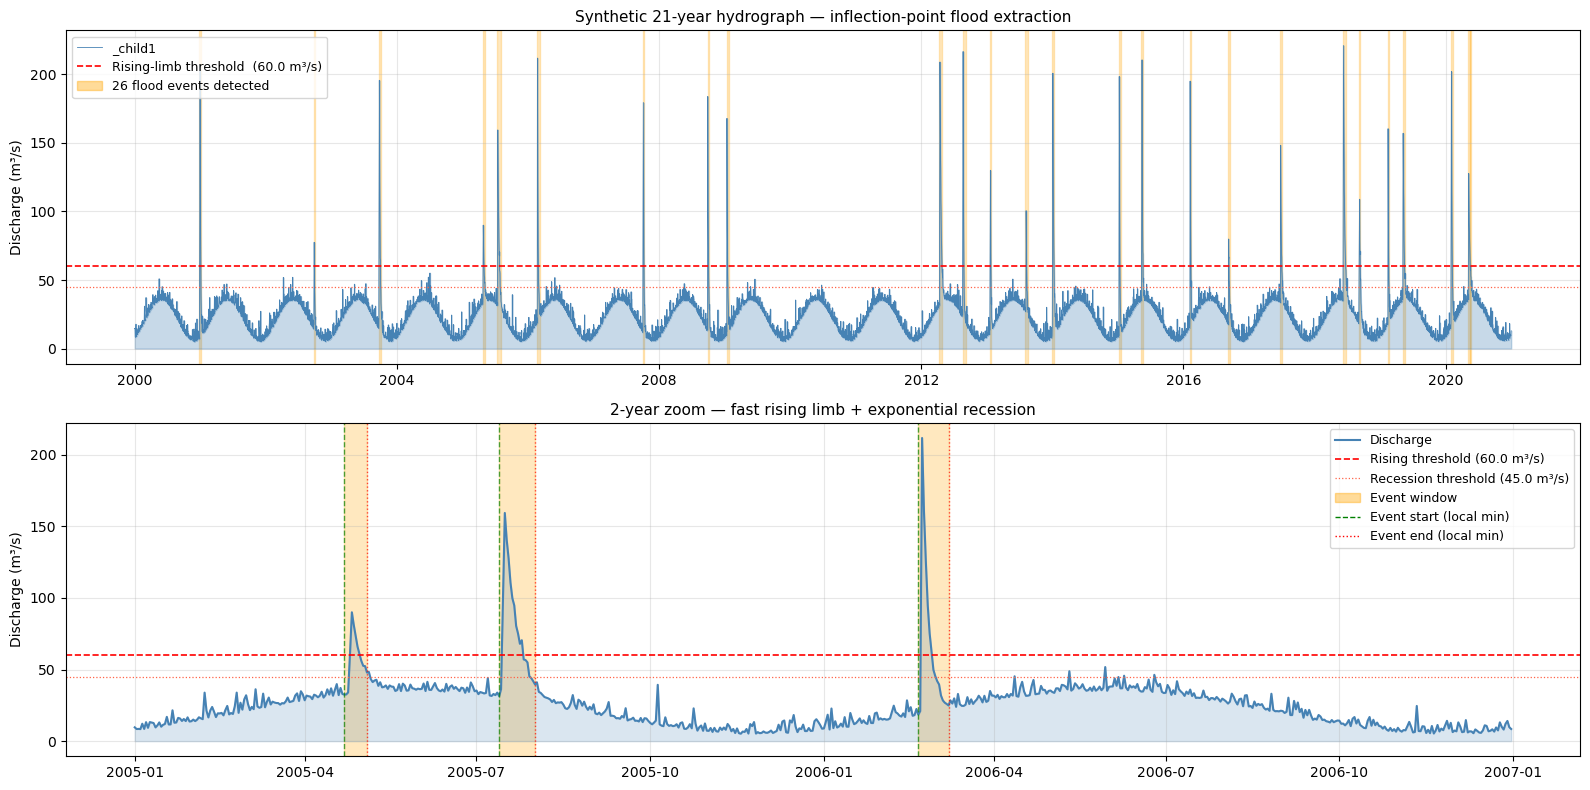

In [6]:
# ── Hydrograph visualisation ──────────────────────────────────────────────────
# Top panel   : full 21-year series with event windows shaded
# Bottom panel: 2-year zoom showing the realistic flood shape
#               (steep rising limb + exponential recession)

ZOOM = slice("2005", "2006")
Q_zoom = Q_series[ZOOM]
b_zoom = bounds_q[(bounds_q["start"] >= Q_zoom.index[0]) &
                  (bounds_q["end"]   <= Q_zoom.index[-1])]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ── Top: full record ──────────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(Q_series.index, Q_series.values, alpha=0.3, color="steelblue")
ax.plot(Q_series.index, Q_series.values, lw=0.6, color="steelblue")
for _, row in bounds_q.iterrows():
    ax.axvspan(row["start"], row["end"], alpha=0.25, color="orange", zorder=0)
ax.axhline(THRESHOLD,  color="red",    lw=1.2, ls="--",
           label=f"Rising-limb threshold  ({THRESHOLD} m³/s)")
ax.axhline(THRESHOLD2, color="tomato", lw=0.9, ls=":",
           label=f"Recession threshold  ({THRESHOLD2} m³/s)")
orange_patch = mpatches.Patch(color="orange", alpha=0.4,
                               label=f"{len(stats_q)} flood events detected")
ax.legend(handles=[ax.lines[0], ax.lines[1], orange_patch], fontsize=9)
ax.set_ylabel("Discharge (m³/s)", fontsize=10)
ax.set_title("Synthetic 21-year hydrograph — inflection-point flood extraction", fontsize=11)
ax.grid(alpha=0.3)

# ── Bottom: 2-year zoom ───────────────────────────────────────────────────────
ax = axes[1]
ax.fill_between(Q_zoom.index, Q_zoom.values, alpha=0.2, color="steelblue")
ax.plot(Q_zoom.index, Q_zoom.values, lw=1.5, color="steelblue", label="Discharge")
ax.axhline(THRESHOLD,  color="red",    lw=1.2, ls="--",
           label=f"Rising threshold ({THRESHOLD} m³/s)")
ax.axhline(THRESHOLD2, color="tomato", lw=0.9, ls=":",
           label=f"Recession threshold ({THRESHOLD2} m³/s)")
for _, row in b_zoom.iterrows():
    ax.axvspan(row["start"], row["end"], alpha=0.25, color="orange", zorder=0)
    ax.axvline(row["start"], color="green", lw=1.0, ls="--", alpha=0.7,
               label="_nolegend_")
    ax.axvline(row["end"],   color="red",   lw=1.0, ls=":",  alpha=0.7,
               label="_nolegend_")

# Custom legend entries for boundary markers
from matplotlib.lines import Line2D
extra = [
    mpatches.Patch(color="orange", alpha=0.4, label="Event window"),
    Line2D([0], [0], color="green", ls="--", lw=1, label="Event start (local min)"),
    Line2D([0], [0], color="red",   ls=":",  lw=1, label="Event end (local min)"),
]
ax.legend(handles=[ax.lines[0], ax.lines[1], ax.lines[2]] + extra, fontsize=9)
ax.set_ylabel("Discharge (m³/s)", fontsize=10)
ax.set_title("2-year zoom — fast rising limb + exponential recession", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

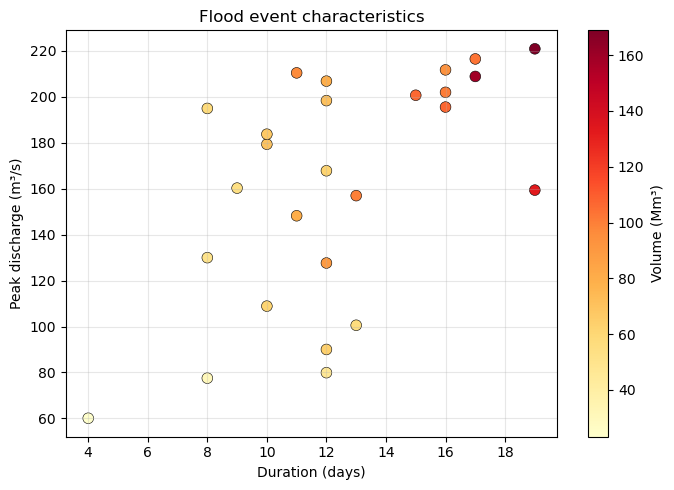

In [7]:
# Peak vs duration scatter coloured by volume
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(stats_q["duration"], stats_q["peak"],
                c=stats_q["volume"] / 1e6, cmap="YlOrRd", s=60, edgecolors="k", lw=0.4)
plt.colorbar(sc, ax=ax, label="Volume (Mm³)")
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Peak discharge (m³/s)")
ax.set_title("Flood event characteristics", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. 🌧️ Precipitation Event Extraction

### 💡 Method: Wet-spell

A **wet spell** is a sequence of consecutive wet days (P > `threshold`) that lasts at
least `min_duration` days. Short dry gaps of ≤ `min_gap` days between two wet runs
are bridged so that a brief dry interruption does not split an otherwise continuous
storm.

**Key parameters**

| Parameter | Physical meaning | Typical value |
|-----------|-----------------|---------------|
| `threshold` | Minimum daily rainfall to consider a day "wet" | 0.1 – 2 mm |
| `min_duration` | Minimum number of consecutive wet days to form an event | 2–3 days |
| `min_gap` | Dry days bridged between two wet runs | 0–2 days |

**When to use**: characterise the frequency, duration and total depth of **all** rainfall
episodes — suitable for water balance, drought indices, irrigation scheduling.

> ⚠️ With a low `min_duration` (e.g. 1–2 days) **most wet days end up as events**
> because even isolated daily showers qualify. Raise `min_duration` to 3–4 days to
> select only sustained multi-day spells.

In [8]:
# Realistic daily precipitation: mixture of two storm types.
#
#  60 % → convective showers (1-2 days, moderate intensity)  — SHORT, will NOT
#           be detected as events when min_duration = 3.
#  40 % → frontal / stratiform rain (3-7 days, lower intensity per day) — LONG,
#           WILL be detected as events.
#
# Both types are separated by dry periods of 3-15 days so the record has clear
# wet/dry alternation and the figure shows isolated vs event days simultaneously.

P_vals = np.zeros(n)
t = 0
n_conv, n_front = 0, 0

while t < n:
    dry_len = int(rng.integers(3, 16))          # inter-storm dry gap
    t += dry_len
    if t >= n:
        break

    if rng.random() < 0.60:                      # 60 % convective (1-2 days)
        storm_dur    = int(rng.integers(1, 3))
        rain_shape   = 1.2
        rain_scale   = 7.0                        # mean ~8 mm/wet day
        n_conv      += 1
    else:                                         # 40 % frontal (3-7 days)
        storm_dur    = int(rng.integers(3, 8))
        rain_shape   = 1.5
        rain_scale   = 10.0                       # mean ~15 mm/wet day
        n_front     += 1

    end          = min(t + storm_dur, n)
    P_vals[t:end] = rng.gamma(rain_shape, rain_scale, end - t)
    t           += storm_dur

P_series = pd.Series(P_vals, index=dates, name="precipitation")
wet_days = (P_vals > 0).sum()

print(f"Storm episodes generated : {n_conv + n_front}  "
      f"(convective: {n_conv}, frontal: {n_front})")
print(f"Wet days                 : {wet_days}  ({100*wet_days/n:.1f} % of total)")
print(f"Mean daily precipitation : {P_series.mean():.2f} mm/day")
print(f"Max daily precipitation  : {P_series.max():.1f} mm")

Storm episodes generated : 646  (convective: 382, frontal: 264)
Wet days                 : 1882  (24.5 % of total)
Mean daily precipitation : 3.19 mm/day
Max daily precipitation  : 79.3 mm


In [9]:
# === WET-SPELL PARAMETERS ===
# threshold    : a day is "wet" if P > 1 mm (standard WMO definition)
# min_duration : require ≥ 3 consecutive wet days → convective 1-2 day showers
#                are excluded; only sustained frontal episodes are captured
# min_gap      : bridge single-day dry interruptions within a frontal spell

THRESHOLD_P   = 1.0   # wet-day threshold (mm) — WMO standard
MIN_DURATION  = 3     # min consecutive wet days to form an event
MIN_GAP       = 1     # dry days bridged (0 = no bridging)

stats_p, bounds_p = extract_precipitation_events(
    series=P_series,
    threshold=THRESHOLD_P,
    min_duration=MIN_DURATION,
    min_gap=MIN_GAP,
)

wet_event_days = sum(
    (bounds_p["end"] - bounds_p["start"]).dt.days + 1
)
pct_event = 100 * wet_event_days / len(P_series)

print(f"Wet-spell events detected : {len(stats_p)}  (~{len(stats_p)/21:.1f}/year)")
print(f"Days inside events        : {wet_event_days}  ({pct_event:.1f} % of the record)")
print(f"  → {100 - pct_event:.1f} % of days are dry or short isolated showers\n")
stats_p.head(8)

Wet-spell events detected : 262  (~12.5/year)
Days inside events        : 1293  (16.9 % of the record)
  → 83.1 % of days are dry or short isolated showers



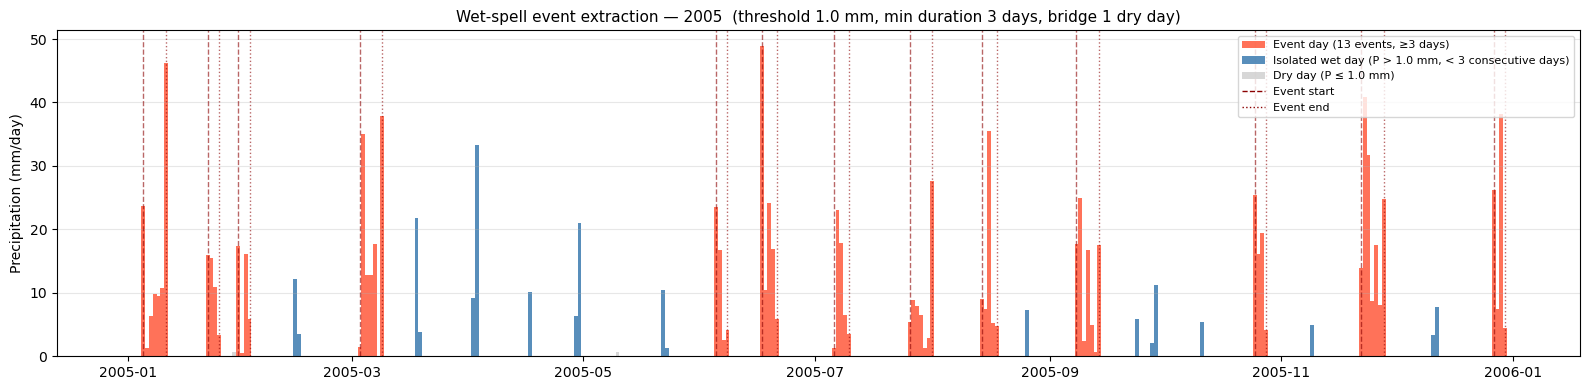

In [10]:
# ── 1-year zoom: three day categories with distinct colours ──────────────────
#   ■ Tomato   = inside a wet-spell event (≥3 consecutive wet days)
#   ■ Steel blue = isolated wet day — real rain but below the duration threshold
#   □ white/empty = dry day (P ≤ 1 mm)

YEAR = "2005"
P_yr   = P_series[YEAR]
b_yr   = bounds_p[(bounds_p["start"] >= P_yr.index[0]) &
                  (bounds_p["end"]   <= P_yr.index[-1])]

event_mask    = np.zeros(len(P_yr), dtype=bool)
for _, row in b_yr.iterrows():
    event_mask[(P_yr.index >= row["start"]) & (P_yr.index <= row["end"])] = True

wet_mask   = P_yr.values > THRESHOLD_P
isolated   = wet_mask & ~event_mask          # wet but not in an event

bar_colors = np.where(event_mask, "tomato",
             np.where(isolated,   "steelblue", "lightgrey"))

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(P_yr.index, P_yr.values, width=1, color=bar_colors, alpha=0.9)

# Event boundary markers
for _, row in b_yr.iterrows():
    ax.axvline(row["start"], color="darkred", lw=1.0, ls="--", alpha=0.6)
    ax.axvline(row["end"],   color="darkred", lw=1.0, ls=":",  alpha=0.6)

# ── Legend ────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor="tomato",    alpha=0.9,  label=f"Event day ({b_yr.shape[0]} events, ≥{MIN_DURATION} days)"),
    Patch(facecolor="steelblue", alpha=0.9,  label=f"Isolated wet day (P > {THRESHOLD_P} mm, < {MIN_DURATION} consecutive days)"),
    Patch(facecolor="lightgrey", alpha=0.9,  label=f"Dry day (P ≤ {THRESHOLD_P} mm)"),
    Line2D([0], [0], color="darkred", ls="--", lw=1, label="Event start"),
    Line2D([0], [0], color="darkred", ls=":",  lw=1, label="Event end"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper right")
ax.set_ylabel("Precipitation (mm/day)", fontsize=10)
ax.set_title(
    f"Wet-spell event extraction — {YEAR}  "
    f"(threshold {THRESHOLD_P} mm, min duration {MIN_DURATION} days, bridge {MIN_GAP} dry day)",
    fontsize=11,
)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

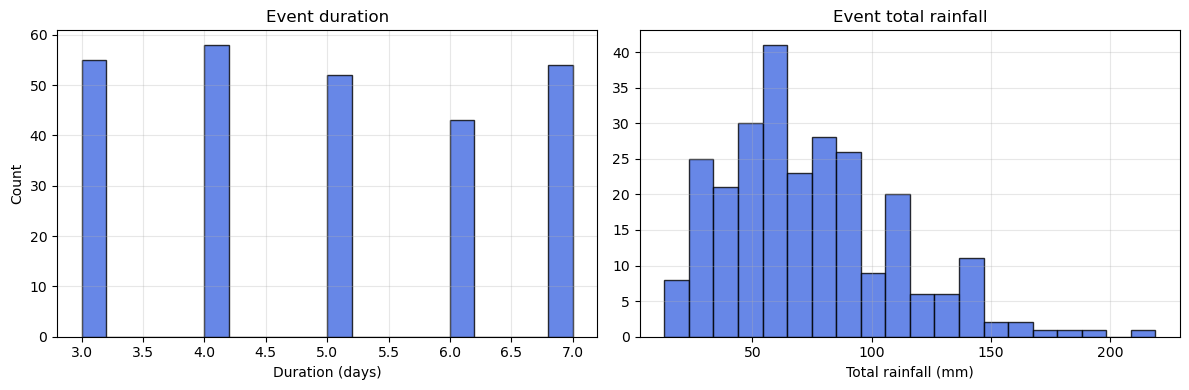

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(stats_p["duration"], bins=20, color="royalblue", alpha=0.8, edgecolor="k")
axes[0].set_xlabel("Duration (days)")
axes[0].set_ylabel("Count")
axes[0].set_title("Event duration")
axes[0].grid(alpha=0.3)

axes[1].hist(stats_p["total"], bins=20, color="royalblue", alpha=0.8, edgecolor="k")
axes[1].set_xlabel("Total rainfall (mm)")
axes[1].set_title("Event total rainfall")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. 🌧️ Precipitation — Peak-over-Threshold (POT)

### 💡 Method

1. Select all days where **P > u** (a high threshold — typically the 90th–95th percentile
   of wet-day rainfall).
2. Group exceedances within **min_sep** days into a single cluster (**declustering**) so
   that two peaks during the same storm are not counted as two independent events.
3. Retain the **peak day** of each cluster; expand the event window to the surrounding
   contiguous wet spell.

**Key parameters**

| Parameter | Physical meaning | Typical value |
|-----------|-----------------|---------------|
| `threshold` | High daily rainfall — e.g. 90th percentile of wet days | 20–50 mm |
| `min_sep` | Max days between two exceedances still in the same cluster | 5–14 days |

**When to use**: **frequency analysis** (fitting a GPD or GEV to the extracted peaks).
The declustering ensures near-independence of events, a requirement for extreme-value
statistics.  Produces far fewer events than wet-spell (roughly the top 5–10 % of storms).

In [12]:
# Use the 90th percentile of wet-day rainfall as POT threshold
wet_vals = P_series[P_series > 0]
THRESHOLD_POT = float(np.percentile(wet_vals, 90))
print(f"90th percentile of wet-day rainfall: {THRESHOLD_POT:.1f} mm  (used as POT threshold)")

stats_pot, bounds_pot = extract_precipitation_events_pot(
    series=P_series,
    threshold=THRESHOLD_POT,
    min_sep=7,            # two exceedances within 7 days → same event
)
print(f"POT events detected: {len(stats_pot)}")
print(f"  → ~{len(stats_pot)/21:.1f} events/year  (vs {len(stats_p)/21:.1f} from wet-spell)")
stats_pot.head(8)

90th percentile of wet-day rainfall: 27.8 mm  (used as POT threshold)
POT events detected: 140
  → ~6.7 events/year  (vs 12.5 from wet-spell)


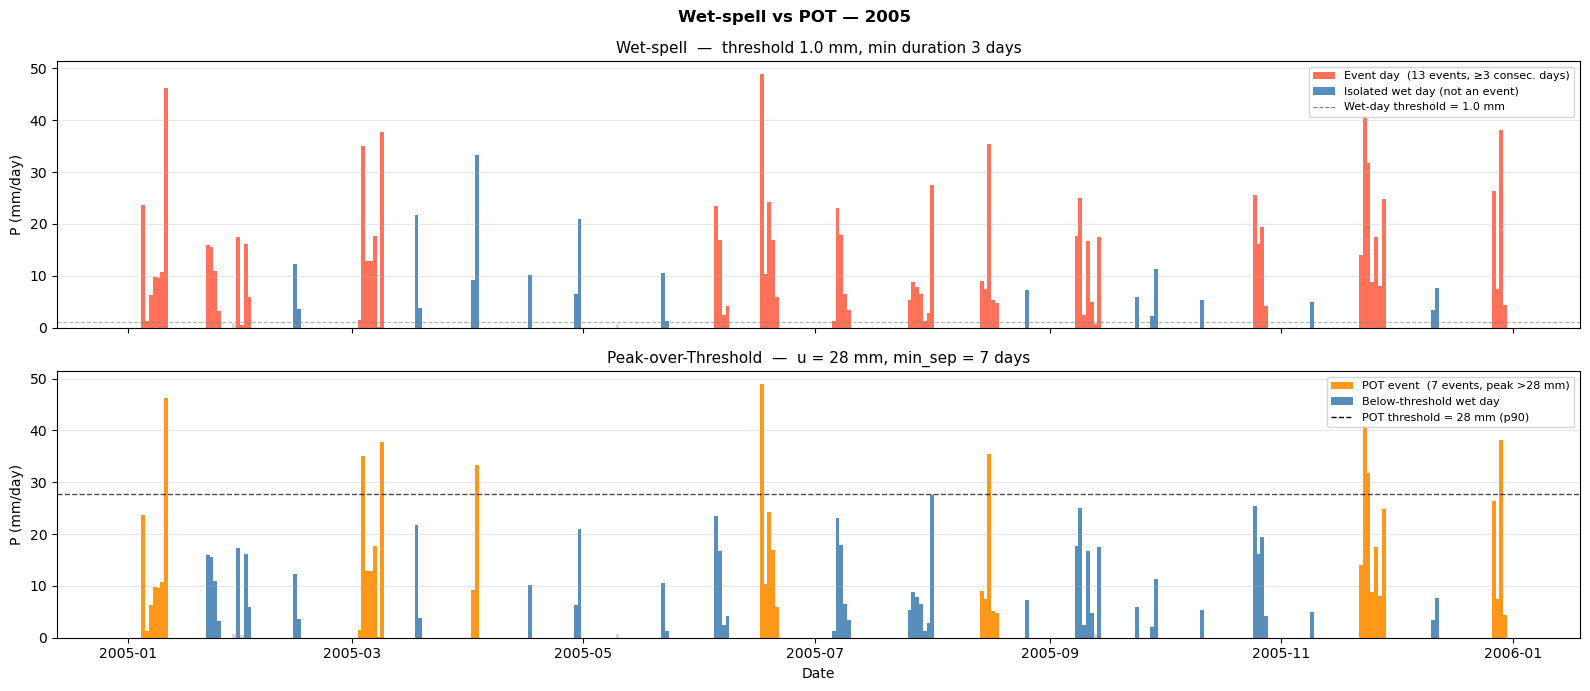

In [13]:
# ── Side-by-side comparison: wet-spell vs POT on the same year ───────────────
# Both panels show the same daily bars; the colour shows which days are
# inside a detected event under each method.

def _event_mask(bounds, index):
    mask = np.zeros(len(index), dtype=bool)
    for _, row in bounds.iterrows():
        mask[(index >= row["start"]) & (index <= row["end"])] = True
    return mask

b_spell_yr = bounds_p[  (bounds_p["start"]   >= P_yr.index[0]) &
                         (bounds_p["end"]     <= P_yr.index[-1])]
b_pot_yr   = bounds_pot[(bounds_pot["start"] >= P_yr.index[0]) &
                         (bounds_pot["end"]   <= P_yr.index[-1])]

mask_spell_yr = _event_mask(b_spell_yr, P_yr.index)
mask_pot_yr   = _event_mask(b_pot_yr,   P_yr.index)
wet_yr        = P_yr.values > THRESHOLD_P

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# ── Wet-spell panel ──────────────────────────────────────────────────────────
ax = axes[0]
colors_s = np.where(mask_spell_yr, "tomato",
           np.where(wet_yr,        "steelblue", "lightgrey"))
ax.bar(P_yr.index, P_yr.values, width=1, color=colors_s, alpha=0.9)
ax.axhline(THRESHOLD_P, color="grey", lw=0.8, ls="--", alpha=0.6,
           label=f"Wet-day threshold ({THRESHOLD_P} mm)")
legend_spell = [
    Patch(facecolor="tomato",    alpha=0.9, label=f"Event day  ({b_spell_yr.shape[0]} events, ≥{MIN_DURATION} consec. days)"),
    Patch(facecolor="steelblue", alpha=0.9, label=f"Isolated wet day (not an event)"),
    Line2D([0],[0], color="grey", ls="--", lw=0.8, label=f"Wet-day threshold = {THRESHOLD_P} mm"),
]
ax.legend(handles=legend_spell, fontsize=8, loc="upper right")
ax.set_ylabel("P (mm/day)", fontsize=10)
ax.set_title(f"Wet-spell  —  threshold {THRESHOLD_P} mm, min duration {MIN_DURATION} days", fontsize=11)
ax.grid(alpha=0.3, axis="y")

# ── POT panel ────────────────────────────────────────────────────────────────
ax = axes[1]
colors_p = np.where(mask_pot_yr,  "darkorange",
           np.where(wet_yr,       "steelblue", "lightgrey"))
ax.bar(P_yr.index, P_yr.values, width=1, color=colors_p, alpha=0.9)
ax.axhline(THRESHOLD_POT, color="k", lw=1.0, ls="--", alpha=0.7,
           label=f"POT threshold ({THRESHOLD_POT:.0f} mm — 90th pct)")
legend_pot = [
    Patch(facecolor="darkorange", alpha=0.9, label=f"POT event  ({b_pot_yr.shape[0]} events, peak >{THRESHOLD_POT:.0f} mm)"),
    Patch(facecolor="steelblue",  alpha=0.9, label="Below-threshold wet day"),
    Line2D([0],[0], color="k", ls="--", lw=1, label=f"POT threshold = {THRESHOLD_POT:.0f} mm (p90)"),
]
ax.legend(handles=legend_pot, fontsize=8, loc="upper right")
ax.set_ylabel("P (mm/day)", fontsize=10)
ax.set_title(f"Peak-over-Threshold  —  u = {THRESHOLD_POT:.0f} mm, min_sep = 7 days", fontsize=11)
ax.grid(alpha=0.3, axis="y")
ax.set_xlabel("Date", fontsize=10)

plt.suptitle(f"Wet-spell vs POT — {YEAR}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. 🌧️ Precipitation — N-day Rolling Accumulation

### 💡 Method

1. Compute the **N-day rolling sum** R(t) = P(t) + P(t-1) + … + P(t-N+1).
2. Identify all periods where R(t) > threshold (default: 90th percentile of non-zero
   rolling sums).
3. Cluster overlapping exceedance windows and retain the N-day period ending at the
   maximum R(t) within each cluster.

**Key parameters**

| Parameter | Physical meaning | Typical value |
|-----------|-----------------|---------------|
| `n_days` | Accumulation window | 3 days (flash floods), 5–10 days (river floods) |
| `threshold` | Minimum N-day total to qualify | 90th pct of rolling sums |

**When to use**: catchments with **slow hydrological response** where a single-day peak
does not tell the full story — the N-day accumulation better reflects antecedent soil
moisture and slow snowmelt-driven floods.  Also used to define design storms for
reservoir sizing.

In [14]:
N_DAYS = 3   # 3-day accumulation window

stats_nday, bounds_nday = extract_precipitation_events_nday(
    series=P_series,
    n_days=N_DAYS,
    threshold=None,     # auto: 90th percentile of non-zero N-day sums
)
print(f"{N_DAYS}-day accumulation events detected: {len(stats_nday)}")
print(f"  → ~{len(stats_nday)/21:.1f} events/year")
stats_nday.head(8)

3-day accumulation events detected: 135
  → ~6.4 events/year


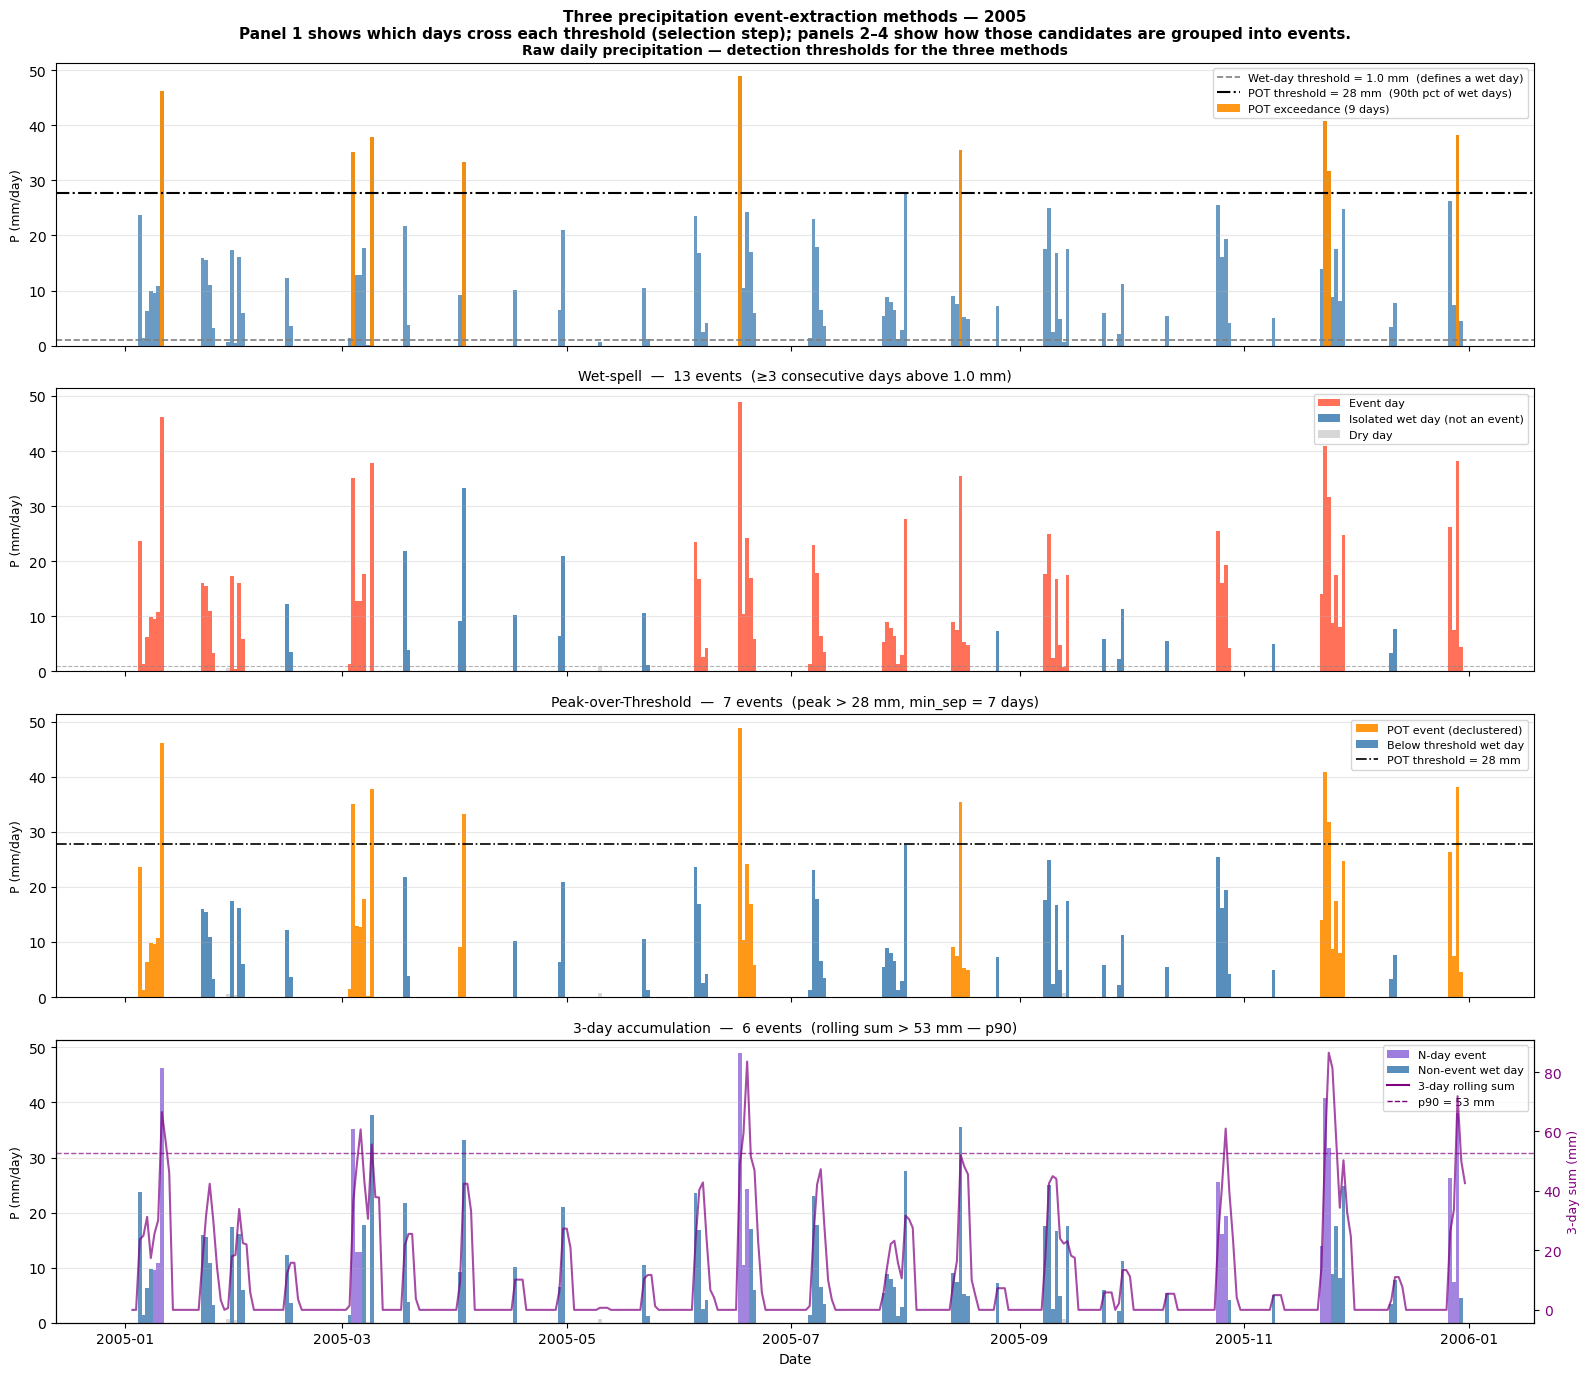

In [15]:
# ── Four-panel comparison: threshold selection → event detection ──────────────
#
# Panel 1  RAW DATA + THRESHOLDS
#   Shows the raw daily record with both detection thresholds overlaid so the
#   reader can see which days are "candidates" under each method before any
#   grouping or declustering is applied.
#
# Panel 2  WET-SPELL
#   Multi-day frontal spells (≥3 consecutive days > 1 mm).
#   Coloured bars: event day (tomato) / isolated wet day (steelblue) / dry (grey).
#
# Panel 3  POT
#   Only the most intense days (peak > p90) after declustering.
#   Threshold line shows which individual bars are exceedances.
#
# Panel 4  N-DAY ACCUMULATION
#   Periods of high 3-day accumulated rainfall (p90 of rolling sums).
#   Secondary axis shows the 3-day rolling sum to make the selection explicit.

b_nday_yr  = bounds_nday[(bounds_nday["start"] >= P_yr.index[0]) &
                          (bounds_nday["end"]   <= P_yr.index[-1])]
mask_nday_yr = _event_mask(b_nday_yr, P_yr.index)
rolling3     = P_yr.rolling(N_DAYS, min_periods=N_DAYS).sum()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# ── Panel 1: raw data + thresholds ────────────────────────────────────────────
ax = axes[0]
ax.bar(P_yr.index, P_yr.values, width=1, color="steelblue", alpha=0.8)
ax.axhline(THRESHOLD_P,   color="grey",  lw=1.2, ls="--",
           label=f"Wet-day threshold = {THRESHOLD_P} mm  (defines a wet day)")
ax.axhline(THRESHOLD_POT, color="black", lw=1.5, ls="-.",
           label=f"POT threshold = {THRESHOLD_POT:.0f} mm  (90th pct of wet days)")
# Shade bars exceeding the POT threshold
exceed_mask = P_yr.values > THRESHOLD_POT
ax.bar(P_yr.index[exceed_mask], P_yr.values[exceed_mask],
       width=1, color="darkorange", alpha=0.9,
       label=f"POT exceedance ({exceed_mask.sum()} days)")
ax.set_ylabel("P (mm/day)", fontsize=9)
ax.set_title("Raw daily precipitation — detection thresholds for the three methods",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3, axis="y")

# ── Panel 2: wet-spell ────────────────────────────────────────────────────────
ax = axes[1]
colors_s = np.where(mask_spell_yr, "tomato",
           np.where(wet_yr,        "steelblue", "lightgrey"))
ax.bar(P_yr.index, P_yr.values, width=1, color=colors_s, alpha=0.9)
ax.axhline(THRESHOLD_P, color="grey", lw=0.8, ls="--", alpha=0.6)
ax.set_ylabel("P (mm/day)", fontsize=9)
ax.set_title(
    f"Wet-spell  —  {b_spell_yr.shape[0]} events  "
    f"(≥{MIN_DURATION} consecutive days above {THRESHOLD_P} mm)",
    fontsize=10,
)
ax.legend(handles=[
    Patch(facecolor="tomato",    alpha=0.9, label="Event day"),
    Patch(facecolor="steelblue", alpha=0.9, label="Isolated wet day (not an event)"),
    Patch(facecolor="lightgrey", alpha=0.9, label="Dry day"),
], fontsize=8, loc="upper right")
ax.grid(alpha=0.3, axis="y")

# ── Panel 3: POT ──────────────────────────────────────────────────────────────
ax = axes[2]
colors_p = np.where(mask_pot_yr,  "darkorange",
           np.where(wet_yr,       "steelblue", "lightgrey"))
ax.bar(P_yr.index, P_yr.values, width=1, color=colors_p, alpha=0.9)
ax.axhline(THRESHOLD_POT, color="black", lw=1.2, ls="-.",
           label=f"POT threshold = {THRESHOLD_POT:.0f} mm (p90)")
ax.set_ylabel("P (mm/day)", fontsize=9)
ax.set_title(
    f"Peak-over-Threshold  —  {b_pot_yr.shape[0]} events  "
    f"(peak > {THRESHOLD_POT:.0f} mm, min_sep = 7 days)",
    fontsize=10,
)
ax.legend(handles=[
    Patch(facecolor="darkorange", alpha=0.9, label="POT event (declustered)"),
    Patch(facecolor="steelblue",  alpha=0.9, label="Below threshold wet day"),
    Line2D([0],[0], color="black", ls="-.", lw=1.2,
           label=f"POT threshold = {THRESHOLD_POT:.0f} mm"),
], fontsize=8, loc="upper right")
ax.grid(alpha=0.3, axis="y")

# ── Panel 4: N-day accumulation with rolling sum overlay ─────────────────────
ax  = axes[3]
ax2 = ax.twinx()
colors_n = np.where(mask_nday_yr, "mediumpurple",
           np.where(wet_yr,       "steelblue", "lightgrey"))
ax.bar(P_yr.index, P_yr.values, width=1, color=colors_n, alpha=0.85)

# Compute threshold for the rolling sum (same logic as extract_precipitation_events_nday)
rolling_full  = P_series.rolling(N_DAYS, min_periods=N_DAYS).sum()
nday_thresh   = float(np.nanpercentile(rolling_full[rolling_full > 0], 90))
ax2.plot(P_yr.index, rolling3.values, color="purple", lw=1.5, alpha=0.7,
         label=f"{N_DAYS}-day rolling sum")
ax2.axhline(nday_thresh, color="purple", lw=1.0, ls="--", alpha=0.7,
            label=f"p90 threshold = {nday_thresh:.0f} mm")
ax2.set_ylabel(f"{N_DAYS}-day sum (mm)", fontsize=9, color="purple")
ax2.tick_params(axis="y", labelcolor="purple")

ax.set_ylabel("P (mm/day)", fontsize=9)
ax.set_xlabel("Date", fontsize=10)
ax.set_title(
    f"{N_DAYS}-day accumulation  —  {b_nday_yr.shape[0]} events  "
    f"(rolling sum > {nday_thresh:.0f} mm — p90)",
    fontsize=10,
)
ax.legend(handles=[
    Patch(facecolor="mediumpurple", alpha=0.9, label="N-day event"),
    Patch(facecolor="steelblue",    alpha=0.9, label="Non-event wet day"),
    Line2D([0],[0], color="purple", lw=1.5,        label=f"{N_DAYS}-day rolling sum"),
    Line2D([0],[0], color="purple", lw=1.0, ls="--", label=f"p90 = {nday_thresh:.0f} mm"),
], fontsize=8, loc="upper right")
ax.grid(alpha=0.3, axis="y")

plt.suptitle(
    f"Three precipitation event-extraction methods — {YEAR}\n"
    "Panel 1 shows which days cross each threshold (selection step); "
    "panels 2–4 show how those candidates are grouped into events.",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## 3. 🔀 Unified Interface: `extract_events`

`extract_events` is a single entry point that routes to the correct method based on the `variable` argument.

In [16]:
# All three precipitation methods are also available through the unified interface.
# Parameters here must match those used in the sections above for consistency.

# Discharge
stats_u, bounds_u = extract_events(
    series=Q_series, threshold=60.0, variable="discharge", threshold2=45.0
)
print(f"Discharge events : {len(stats_u)}")

# Precipitation — wet-spell (same parameters as Section 2)
stats_spell_u, _ = extract_events(
    series=P_series, variable="precipitation", method="spell",
    threshold=THRESHOLD_P, min_duration=MIN_DURATION, min_gap=MIN_GAP,
)
# Precipitation — POT (same parameters as Section 3)
stats_pot_u, _ = extract_events(
    series=P_series, variable="precipitation", method="pot",
    threshold=THRESHOLD_POT, min_sep=7,
)
# Precipitation — 3-day accumulation (same parameters as Section 4)
stats_nday_u, _ = extract_events(
    series=P_series, variable="precipitation", method="nday",
    threshold=None, n_days=N_DAYS,
)

print(f"\nPrecipitation events")
print(f"  Wet-spell (≥{MIN_DURATION} days, >{THRESHOLD_P} mm) : {len(stats_spell_u):>4}  (~{len(stats_spell_u)/21:.1f}/yr)")
print(f"  POT (peak >{THRESHOLD_POT:.0f} mm, sep 7d)       : {len(stats_pot_u):>4}  (~{len(stats_pot_u)/21:.1f}/yr)")
print(f"  {N_DAYS}-day accumulation (p90 threshold)   : {len(stats_nday_u):>4}  (~{len(stats_nday_u)/21:.1f}/yr)")

Discharge events : 26

Precipitation events
  Wet-spell (≥3 days, >1.0 mm) :  262  (~12.5/yr)
  POT (peak >28 mm, sep 7d)       :  140  (~6.7/yr)
  3-day accumulation (p90 threshold)   :  135  (~6.4/yr)


---
## 5. 🗺️ Concurrent / Compound Events

### 💡 Concept

A **concurrent event** (or **compound event**) occurs when an extreme episode at one
station coincides with unusual conditions at other stations in the same region.
Identifying concurrent events is essential for:

- **Compound flood risk**: did the same storm produce extreme rainfall across several
  sub-catchments simultaneously?
- **Spatial coherence analysis**: which stations respond together vs independently?
- **Multivariate frequency analysis**: build a joint dataset of peaks for copula fitting
  or Max-stable process modelling.

### 💡 Method: `extract_concurrent_events`

Given:
1. A set of **event windows** detected at a *target* station (output of any
   `extract_*_events` function).
2. A **dictionary of series** for all stations in the region.

The function extracts max / mean / total precipitation at every station *during each
target event window* (optionally extended by `buffer_days` on each side to capture
lagged downstream responses).

**Key parameters**

| Parameter | Physical meaning | Typical value |
|-----------|-----------------|---------------|
| `event_bounds` | Event windows detected at the target station | output of `extract_precipitation_events_pot` |
| `series_dict` | `{name: pd.Series}` for all stations | region-wide network |
| `buffer_days` | Extend each window ± N days to capture lagged responses | 0–3 days |
| `stats` | Statistics to compute: `'max'`, `'mean'`, `'total'` | all three |

In [17]:
# Generate 5 spatially-correlated precipitation series for a region.
#
# Architecture: each station = common_forcing × regional_multiplier + station noise.
# This produces positive spatial correlation (extreme events tend to be
# co-located) while preserving station-to-station variability in mean and variance.

STATIONS = ["St_A (target)", "St_B", "St_C", "St_D", "St_E"]
rng2 = np.random.default_rng(99)

# Regional multipliers and independent noise fractions
multipliers  = [1.00, 0.85, 1.15, 0.70, 1.05]
noise_frac   = [0.00, 0.18, 0.28, 0.35, 0.22]   # relative noise per station

station_series = {}
for name, mult, nf in zip(STATIONS, multipliers, noise_frac):
    noise  = rng2.normal(0, P_series.mean() * nf, n)
    vals   = P_series.values * mult + noise
    vals   = np.maximum(vals, 0.0)
    station_series[name] = pd.Series(vals, index=dates, name=name)

print("Station statistics:")
print(f"  {'Station':<22} {'Mean (mm/day)':>14}  {'Max (mm/day)':>13}  {'Wet days (%)':>13}")
for name, s in station_series.items():
    wet_pct = 100 * (s > 1.0).mean()
    print(f"  {name:<22} {s.mean():>14.2f}  {s.max():>13.1f}  {wet_pct:>12.1f}%")

Station statistics:
  Station                 Mean (mm/day)   Max (mm/day)   Wet days (%)
  St_A (target)                    3.19           79.3          23.5%
  St_B                             2.88           67.8          26.5%
  St_C                             3.94           92.0          33.9%
  St_D                             2.57           56.6          35.8%
  St_E                             3.55           83.1          28.8%


In [18]:
# Detect POT extreme events at the TARGET station (St_A).
# Use p90 of wet-day rainfall as threshold; min_sep=7 days for declustering.

target_series = station_series["St_A (target)"]
wet_target    = target_series[target_series > 0]
THRESH_TARGET = float(np.percentile(wet_target, 90))

_, bounds_target = extract_precipitation_events_pot(
    series=target_series,
    threshold=THRESH_TARGET,
    min_sep=7,
)

print(f"Target station POT threshold (p90 of wet days): {THRESH_TARGET:.1f} mm")
print(f"Extreme events at target station: {len(bounds_target)}  (~{len(bounds_target)/21:.1f}/yr)")

# Extract concurrent conditions at ALL stations during each target event.
# buffer_days=2: extend the window ±2 days to capture lagged responses.
concurrent = extract_concurrent_events(
    event_bounds=bounds_target,
    series_dict=station_series,
    buffer_days=2,
    stats=("max", "total"),
)

print(f"\nConcurrent event table: {concurrent.shape[0]} events × {concurrent.shape[1]} columns")
print("Columns:", list(concurrent.columns))
concurrent.head(6)

Target station POT threshold (p90 of wet days): 27.8 mm
Extreme events at target station: 140  (~6.7/yr)

Concurrent event table: 140 events × 12 columns
Columns: ['event_start', 'event_end', 'St_A (target)_max', 'St_A (target)_total', 'St_B_max', 'St_B_total', 'St_C_max', 'St_C_total', 'St_D_max', 'St_D_total', 'St_E_max', 'St_E_total']


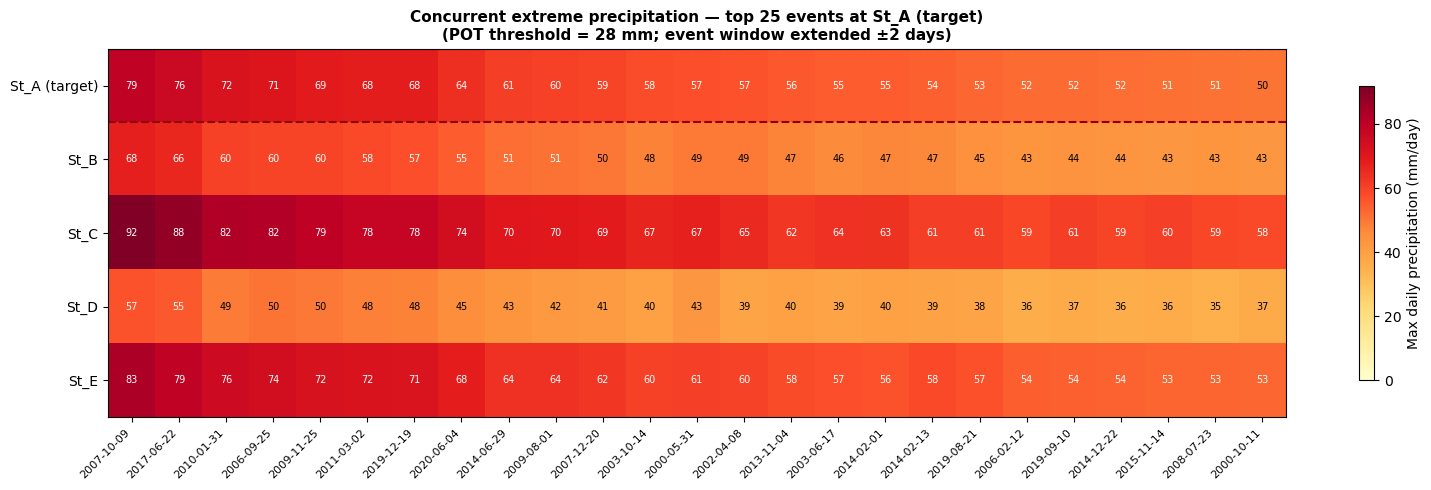

In [19]:
# ── Heatmap: max precipitation at each station during extreme events at St_A ──
#
# Rows = stations, columns = individual events (sorted by St_A peak, descending).
# Shows at a glance which events are truly regional (high across all stations)
# vs purely local extremes confined to St_A.

max_cols  = [f"{s}_max" for s in STATIONS]
heat_data = concurrent[max_cols].copy()
heat_data.columns = STATIONS
heat_data.index   = concurrent["event_start"].dt.strftime("%Y-%m-%d")

# Sort by target station intensity, show top 25 events
heat_data = heat_data.sort_values(STATIONS[0], ascending=False).head(25)

fig, ax = plt.subplots(figsize=(16, 5))
vmax = heat_data.values.max()
im   = ax.imshow(heat_data.T.values, aspect="auto", cmap="YlOrRd",
                  vmin=0, vmax=vmax)

ax.set_xticks(range(len(heat_data)))
ax.set_xticklabels(heat_data.index, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(STATIONS)))
ax.set_yticklabels(STATIONS, fontsize=10)

# Annotate cells with values
for i in range(len(STATIONS)):
    for j in range(len(heat_data)):
        val = heat_data.T.values[i, j]
        tc  = "white" if val > vmax * 0.55 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=7, color=tc)

# Threshold reference line on target row
ax.axhline(-0.5, color="darkred", lw=1.5, ls="--")
ax.axhline( 0.5, color="darkred", lw=1.5, ls="--")

plt.colorbar(im, ax=ax, label="Max daily precipitation (mm/day)", shrink=0.8)
ax.set_title(
    f"Concurrent extreme precipitation — top 25 events at {STATIONS[0]}\n"
    f"(POT threshold = {THRESH_TARGET:.0f} mm; event window extended ±2 days)",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

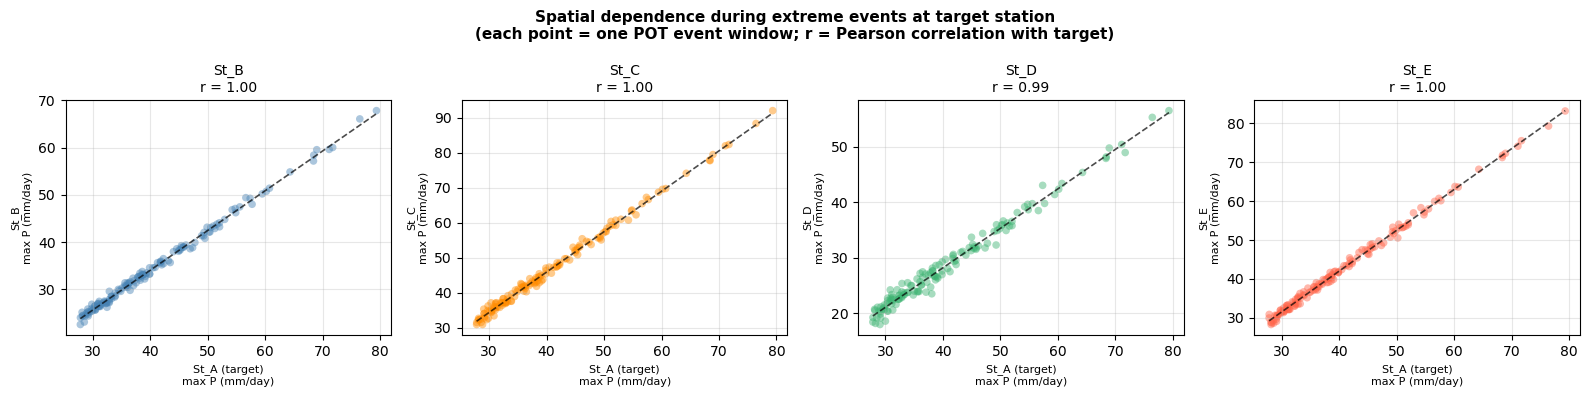

In [20]:
# ── Scatter plots: spatial dependence during concurrent events ─────────────────
#
# Each panel compares St_A (target) max precipitation vs one other station.
# The Pearson r in the title quantifies how often an extreme at St_A is also
# extreme at that neighbour — a measure of spatial compound risk.
#
# High r → regional storm (all stations affected simultaneously)
# Low r  → local storm or large spatial variability

target_col     = f"{STATIONS[0]}_max"
other_stations = STATIONS[1:]
scatter_colors = ["steelblue", "darkorange", "mediumseagreen", "tomato"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, name, color in zip(axes, other_stations, scatter_colors):
    other_col = f"{name}_max"
    x = concurrent[target_col].values
    y = concurrent[other_col].values
    r = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, alpha=0.45, s=30, color=color, edgecolors="none")
    # regression line
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color="black", lw=1.2, ls="--", alpha=0.7)
    ax.set_xlabel(f"{STATIONS[0]}\nmax P (mm/day)", fontsize=8)
    ax.set_ylabel(f"{name}\nmax P (mm/day)", fontsize=8)
    ax.set_title(f"{name}\nr = {r:.2f}", fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Spatial dependence during extreme events at target station\n"
    "(each point = one POT event window; r = Pearson correlation with target)",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## ✅ Method selection guide

Choosing the right extraction method determines what enters your frequency analysis 
or copula fitting. Use the table below to match method to purpose.

### Precipitation methods

| Question / Use case | Method | Why |
|--------------------|--------|-----|
| Flood frequency analysis (GEV / GPD) | **POT** | Declustered peaks are near-independent; maximises events per year |
| Water balance, irrigation scheduling | **Wet-spell** | Captures total volume of each rainfall episode |
| Slow-response catchments (> 3-day concentration time) | **N-day accumulation** | Single-day peak understates antecedent soil moisture contribution |
| Design storm for reservoirs | **N-day accumulation** (n=5–10 days) | Matches the integration time scale of reservoir routing |
| Multi-site compound analysis | **POT** at target + `extract_concurrent_events` | Declustered peaks give independent events with well-defined windows |

### Threshold guidance

| Method | Too low a threshold | Too high a threshold |
|--------|--------------------|--------------------|
| **POT** | Many clustered exceedances; independence violated | < 10 events/year; poor GPD fit |
| **Wet-spell min_duration** | Every shower becomes an event (many spurious events) | Only prolonged frontal episodes detected; misses convective rain |
| **N-day accumulation** | Threshold always exceeded (entire record is "events") | Very few events; high sampling variance |

**Rule of thumb for POT:** choose threshold so that λ ≈ 3–10 events/year. 
Below 3 events/year you don't have enough data; above 10 events/year, 
independence between successive events becomes uncertain.

### Discharge threshold guidance

| Objective | `threshold` | `threshold2` |
|-----------|-------------|-------------|
| Detect all flood events including minor peaks | 1.5 × mean flow | 1.0 × mean flow |
| Detect only significant floods | Q75 – Q90 | Q50 – Q75 |
| Frequency analysis (few independent peaks) | Q95 | Q90 |

`threshold2 < threshold` creates a hysteresis band: the event must 
rise above `threshold` to start, but may recede to the lower `threshold2` 
before the algorithm ends the event window. This avoids splitting 
multi-peak floods into separate events.

### When methods agree and disagree

| Situation | Implication |
|-----------|-------------|
| Wet-spell and POT give similar events | Storms are well-clustered; most wet-spell events have a single dominant peak |
| Wet-spell detects 3× more events than POT | Many low-intensity spells; extremes are rare relative to ordinary episodes |
| N-day accumulation and POT disagree on event order (different events ranked highest) | Multi-day accumulation changes the "severity" ranking — consider both metrics for design |
